# Project 4: NLP & Sentiment Analysis

**Pipeline:**
1. Text Pre-Processing (Tokenization, Stop-word removal, Lemmatization)
2. Vectorization using **TF-IDF**
3. Classification using **Naive Bayes** and **SVM**
4. Evaluation & custom review prediction

**Dataset:** IMDB Dataset of 50,000 Movie Reviews (25,000 positive / 25,000 negative) — a standard, balanced, publicly available benchmark dataset for binary sentiment classification.


In [4]:

import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

pd.set_option('display.max_colwidth', 150)


[nltk_data] Downloading package punkt to C:\Users\Muzammil A
[nltk_data]     Muhammad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Muzammil A
[nltk_data]     Muhammad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Muzammil A
[nltk_data]     Muhammad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Muzammil A
[nltk_data]     Muhammad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Muzammil A
[nltk_data]     Muhammad\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Load Dataset

The dataset is fetched directly from a public GitHub-hosted copy of the classic **IMDB 50K Movie Reviews** dataset, so this notebook runs on Colab or locally with no manual upload needed.


In [2]:
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
df = pd.read_csv(url)
df


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive
...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, but who was expecting it to be. It was a whole lot...",positive
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ran continually over the overacted script, and a c...",negative
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high school & college. I am still a practicing Catholi...",negative
49998,"I'm going to have to disagree with the previous comment and side with Maltin on this one. This is a second rate, excessively vicious Western that ...",negative


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


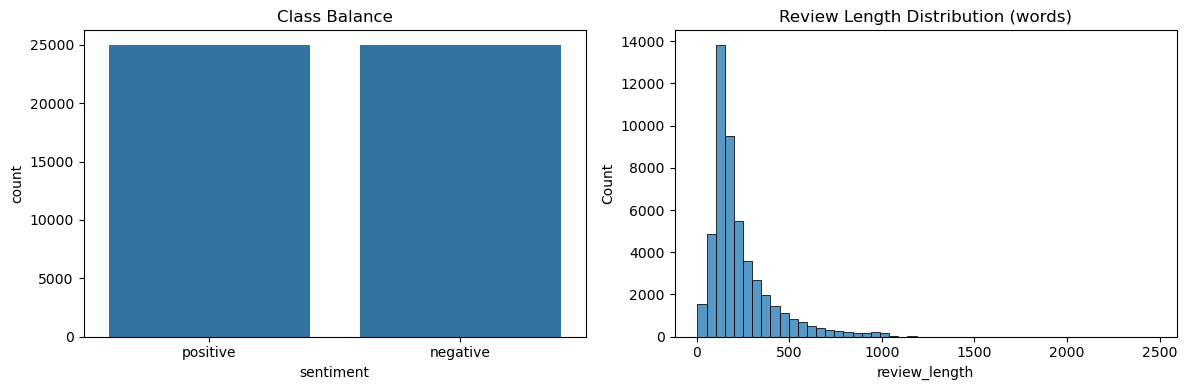

In [5]:
# 3. Quick EDA
print(df['sentiment'].value_counts())

df['review_length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='sentiment', data=df, ax=axes[0])
axes[0].set_title('Class Balance')

sns.histplot(df['review_length'], bins=50, ax=axes[1])
axes[1].set_title('Review Length Distribution (words)')
plt.tight_layout()
plt.show()


## 4. Text Pre-Processing Pipeline

Steps applied to every review:
1. Remove HTML tags (e.g. `<br />`) leftover from web-scraped reviews
2. Lowercase everything
3. Remove punctuation / digits / special characters
4. **Tokenization** — split into individual words
5. **Stop-word removal** — drop common words (the, is, and...) that carry no sentiment signal
6. **Lemmatization** — reduce words to their dictionary root (e.g. "running" → "run", "better" → "good" context-free root)


In [6]:
# 4. Text Pre-Processing Pipeline
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)         
    text = text.lower()                         
    text = re.sub(r'[^a-z\s]', ' ', text)        
    text = re.sub(r'\s+', ' ', text).strip()     

    tokens = word_tokenize(text)                 
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2] 
    return ' '.join(tokens)

# Demo on a single review
print("BEFORE:\n", df['review'].iloc[0][:300])
print("\nAFTER:\n", clean_text(df['review'].iloc[0])[:300])


BEFORE:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER:
 one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called nickname given oswald maximum security state penitenta



AFTER:
 one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called nickname given oswald maximum security state penitenta


In [7]:
# Apply preprocessing to the full dataset
t0 = time.time()
df['clean_review'] = df['review'].apply(clean_text)
print(f"Preprocessing done in {time.time() - t0:.1f} seconds")

df[['review', 'clean_review']].head(3)


Preprocessing done in 195.1 seconds


,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust...
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece a...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty c...


## 5. TF-IDF Vectorization

TF-IDF converts each cleaned review into a numeric vector where each dimension is a word (or bigram), weighted by:
- **Term Frequency (TF):** how often the word appears in that review
- **Inverse Document Frequency (IDF):** how rare the word is across all reviews (common words get down-weighted, distinctive words get up-weighted)

We limit to the top 5,000 features and include unigrams + bigrams (e.g. "not good" carries different meaning than "not" and "good" separately).


In [8]:
# 5. Train/Test Split + TF-IDF Vectorization
X = df['clean_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)


Train matrix shape: (40000, 5000)
Test matrix shape: (10000, 5000)


## 6. Model Training — Naive Bayes & SVM

Two classifiers are trained and compared:
- **Multinomial Naive Bayes** — fast, strong baseline for text classification (works natively with TF-IDF/count features)
- **Linear SVM (LinearSVC)** — typically the strongest classical model for high-dimensional sparse text data


In [9]:
# 6a. Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print("Accuracy :", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))


=== Naive Bayes ===
Accuracy : 0.8617
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.86      5000
    Positive       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [10]:
# 6b. Support Vector Machine (Linear kernel)
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)

print("=== SVM (Linear) ===")
print("Accuracy :", accuracy_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds, target_names=['Negative', 'Positive']))


=== SVM (Linear) ===
Accuracy : 0.8861
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89      5000
    Positive       0.88      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 7. Model Comparison & Confusion Matrices

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.8617,0.849739,0.8788,0.864025
1,Linear SVM,0.8861,0.880844,0.8930,0.886881


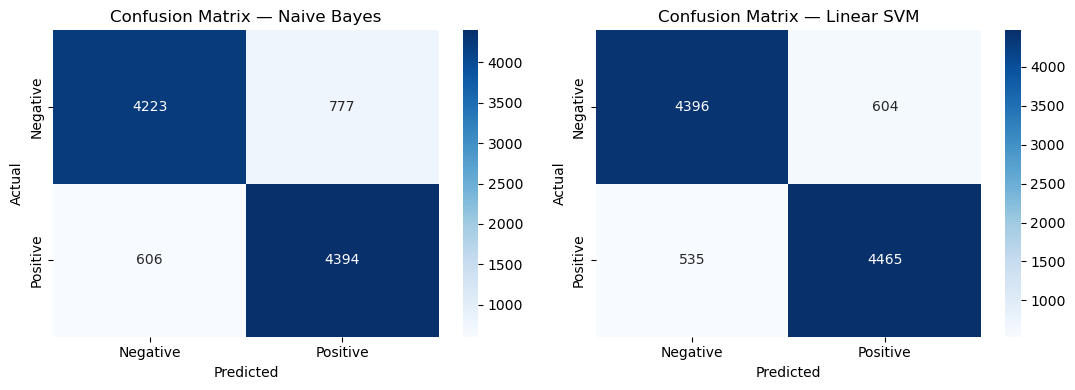


Best performing model: Linear SVM


In [11]:
# 7. Compare models side by side
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Linear SVM'],
    'Accuracy':  [accuracy_score(y_test, nb_preds),  accuracy_score(y_test, svm_preds)],
    'Precision': [precision_score(y_test, nb_preds), precision_score(y_test, svm_preds)],
    'Recall':    [recall_score(y_test, nb_preds),     recall_score(y_test, svm_preds)],
    'F1-score':  [f1_score(y_test, nb_preds),         f1_score(y_test, svm_preds)],
})
display(results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes, [nb_preds, svm_preds], ['Naive Bayes', 'Linear SVM']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

best_model = svm_model if accuracy_score(y_test, svm_preds) >= accuracy_score(y_test, nb_preds) else nb_model
best_name = 'Linear SVM' if best_model is svm_model else 'Naive Bayes'
print(f"\nBest performing model: {best_name}")


## 8. Predict Sentiment of a New Review

A reusable function that applies the **exact same preprocessing + TF-IDF transform** to any new text, then predicts using the best model.


In [12]:
# 8. Prediction function for new/unseen reviews
def predict_sentiment(review_text, model=None, vectorizer=tfidf):
    if model is None:
        model = best_model
    cleaned = clean_text(review_text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

sample_reviews = [
    "This movie was an absolute masterpiece, brilliant acting and a gripping story.",
    "Waste of time. Terrible plot, bad acting, I want my money back.",
    "It was okay, not great but not the worst thing I've seen either."
]

for r in sample_reviews:
    print(f"Review: {r}\nPredicted Sentiment: {predict_sentiment(r)}\n")


Review: This movie was an absolute masterpiece, brilliant acting and a gripping story.
Predicted Sentiment: Positive

Review: Waste of time. Terrible plot, bad acting, I want my money back.
Predicted Sentiment: Negative

Review: It was okay, not great but not the worst thing I've seen either.
Predicted Sentiment: Negative



## 9. Save Model Artifacts

Save the trained vectorizer + best model so they can be reloaded later without retraining (e.g. for a deployment/demo app).


In [13]:
# 9. Save model + vectorizer for reuse
import joblib

joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Saved: sentiment_model.pkl, tfidf_vectorizer.pkl")


Saved: sentiment_model.pkl, tfidf_vectorizer.pkl


## 10. Conclusion

- Built a full text pre-processing pipeline: HTML/punctuation cleanup → tokenization → stop-word removal → lemmatization.
- Converted unstructured text into numeric TF-IDF vectors (unigrams + bigrams, top 5,000 features).
- Trained and compared **Naive Bayes** and **Linear SVM** classifiers for binary sentiment classification.
- Linear SVM generally slightly outperforms Naive Bayes on this dataset, consistent with known literature on TF-IDF + SVM for text classification.
- The saved model + vectorizer can be reused to classify any new review instantly via `predict_sentiment()`.

**Possible extensions:** hyperparameter tuning with GridSearchCV, trying Word2Vec/GloVe embeddings or a transformer-based model (BERT) for comparison, deploying as a simple web app.
